In [1]:
import numpy as np
import pandas as pd

def build_peptide_protein_q_table(
    protein_csv: str,
    peptide_csv: str,
    *,
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Return a DataFrame with one row per (peptide, protein) pair:

    Columns:
      - peptide
      - peptide_q_value
      - protein
      - protein_q_value
      - is_sig_peptide_discordant : True when peptide_q_value < alpha AND
        (protein_q_value >= alpha OR protein_q_value is NaN). These are the
        points highlighted in red on the scatter plot.
    """
    # --- Load data ---
    df_prot = pd.read_csv(protein_csv)
    df_pep = pd.read_csv(peptide_csv)

    # Basic checks
    for col in ("protein", "q_value"):
        if col not in df_prot.columns:
            raise ValueError(f"Protein CSV missing required column '{col}'")
        if col not in df_pep.columns:
            raise ValueError(f"Peptide CSV missing required column '{col}'")

    # Normalize protein names in protein-level table
    df_prot["protein_norm"] = df_prot["protein"].astype(str).str.strip()

    # --- Parse peptide protein column ---
    # Expect "PEPTIDESEQ(prot1,prot2,...)"
    parsed = df_pep["protein"].astype(str).str.extract(
        r"^\s*([^()]+?)\s*\(([^()]*)\)\s*$"
    )
    parsed.columns = ["peptide", "protein_list_raw"]
    df_pep = df_pep.join(parsed)

    def split_protein_list(s: str):
        if not isinstance(s, str) or s.strip() == "":
            return []
        return [p.strip() for p in s.split(",") if p.strip()]

    df_pep["protein_names"] = df_pep["protein_list_raw"].apply(split_protein_list)

    # Map protein → q_value for quick lookup
    prot_q = df_prot.set_index("protein_norm")["q_value"].to_dict()

    rows = []
    for _, row in df_pep.iterrows():
        pep = row["peptide"]
        pep_q = row["q_value"]
        for prot in row["protein_names"]:
            rows.append({
                "peptide": pep,
                "peptide_q_value": pep_q,
                "protein": prot,
                "protein_q_value": prot_q.get(prot, np.nan)
            })

    result = pd.DataFrame(rows)

    # Flag "significant peptide / non-significant protein" pairs (the red points).
    result["is_sig_peptide_discordant"] = (
        (result["peptide_q_value"] < alpha)
        & ((result["protein_q_value"] >= alpha) | result["protein_q_value"].isna())
    )

    return result


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def plot_peptide_vs_protein_q(
    protein_csv: str,
    peptide_csv: str,
    *,
    alpha: float = 0.05,
    figsize=(6, 6)
):
    """
    Scatter plot:
      x-axis: -log10(protein q_value)
      y-axis: -log10(peptide q_value)

    All points: grey
    Highlighted (red):
      peptide_q < alpha AND protein_q >= alpha (or NaN)

    Also fits a linear regression line and prints slope + R².
    """
    df_pairs = build_peptide_protein_q_table(protein_csv, peptide_csv, alpha=alpha)

    # Compute -log10(q)
    df_pairs["neglog_protein_q"] = -np.log10(df_pairs["protein_q_value"])
    df_pairs["neglog_peptide_q"] = -np.log10(df_pairs["peptide_q_value"])

    # Highlight mask (single source of truth: computed in build_peptide_protein_q_table)
    mask_highlight = df_pairs["is_sig_peptide_discordant"]

    # Regression data (drop NaNs)
    df_clean = df_pairs.dropna(subset=["neglog_protein_q", "neglog_peptide_q"])
    x = df_clean["neglog_protein_q"].values
    y = df_clean["neglog_peptide_q"].values

    # Fit regression
    lr = linregress(x, y)
    slope, intercept, r_sq = lr.slope, lr.intercept, lr.rvalue ** 2

    print(f"Slope:     {slope:.4f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"R²:        {r_sq:.4f}")

    fig, ax = plt.subplots(figsize=figsize)

    # All points
    ax.scatter(
        df_pairs["neglog_protein_q"],
        df_pairs["neglog_peptide_q"],
        s=15,
        alpha=0.4,
        color="grey"
    )

    # Highlight points
    df_high = df_pairs[mask_highlight]
    ax.scatter(
        df_high["neglog_protein_q"],
        df_high["neglog_peptide_q"],
        s=30,
        color="red",
        label="Sig peptide / non-sig protein"
    )

    # Regression line for plotting
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = slope * x_line + intercept
    ax.plot(
        x_line,
        y_line,
        color="blue",
        linewidth=2,
        label=f"Fit (slope={slope:.2f}, R²={r_sq:.2f})"
    )

    ax.set_xlabel("-log10(protein q-value)", fontsize=20)
    ax.set_ylabel("-log10(peptide q-value)", fontsize=20)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=20)
    ax.legend(fontsize=15)

    plt.tight_layout()
    return fig, ax, slope, r_sq


In [3]:
peptide_protein_q_table = build_peptide_protein_q_table(
    "results/proteins-mouse-aging-features-ols.csv",
    "results/peptides-mouse-aging-features-ols.csv",
    alpha=0.01  # match the red-highlight cutoff used in the scatter plot below
)

peptide_protein_q_table.to_csv("results/peptide_protein_q_table.csv", index=False)

Slope:     0.5716
Intercept: 0.1031
R²:        0.6655


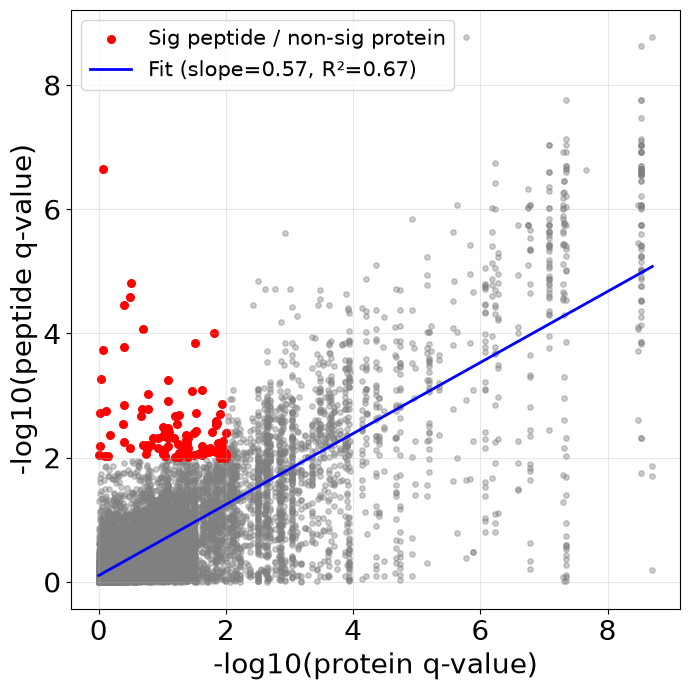

In [4]:
fig, ax, slope, r2 = plot_peptide_vs_protein_q(
    "results/proteins-mouse-aging-features-ols.csv",
    "results/peptides-mouse-aging-features-ols.csv",
    alpha=0.01,
    figsize=(7, 7)
)
plt.show()